Surface totale du cercle: 3.1416
Surface de chaque secteur: 0.0785
Nombre total de secteurs: 40

Rayons des cercles concentriques: ['0.000', '0.447', '0.632', '0.775', '0.894', '1.000']


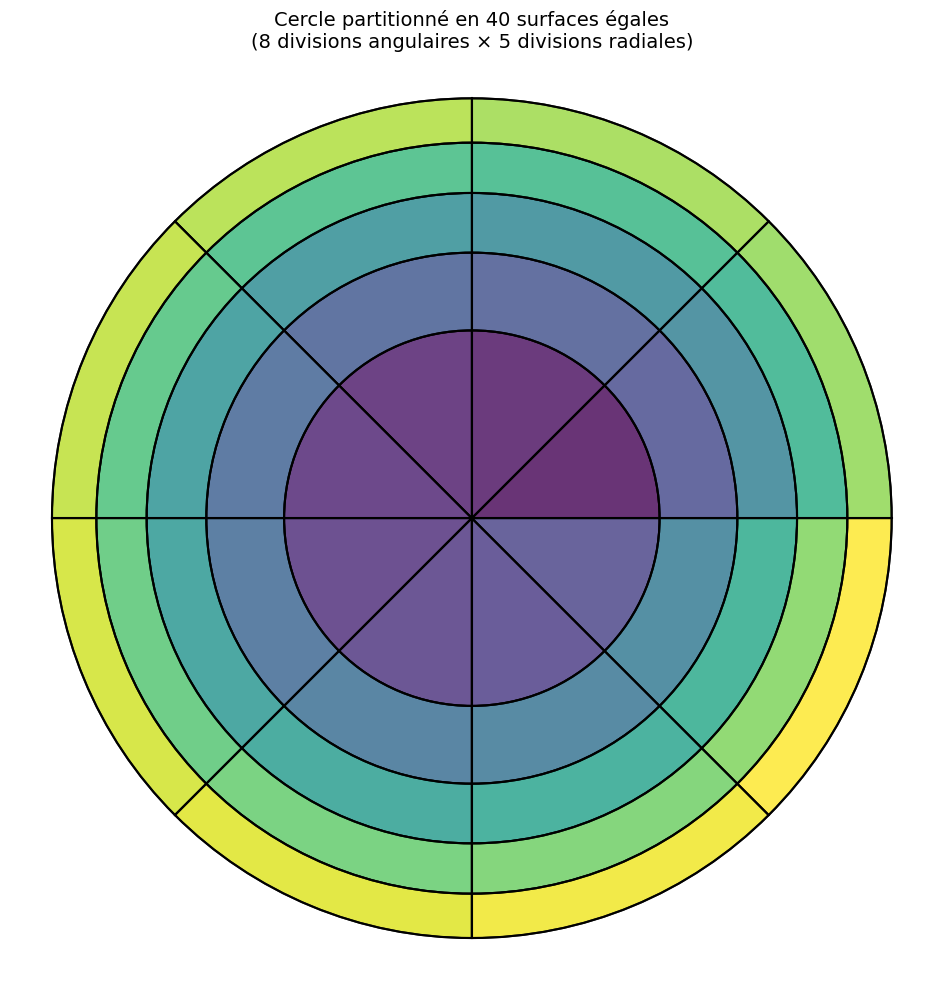

Surface totale du cercle: 3.1416
Surface de chaque secteur: 0.0436
Nombre total de secteurs: 72

Rayons des cercles concentriques: ['0.000', '0.408', '0.577', '0.707', '0.816', '0.913', '1.000']


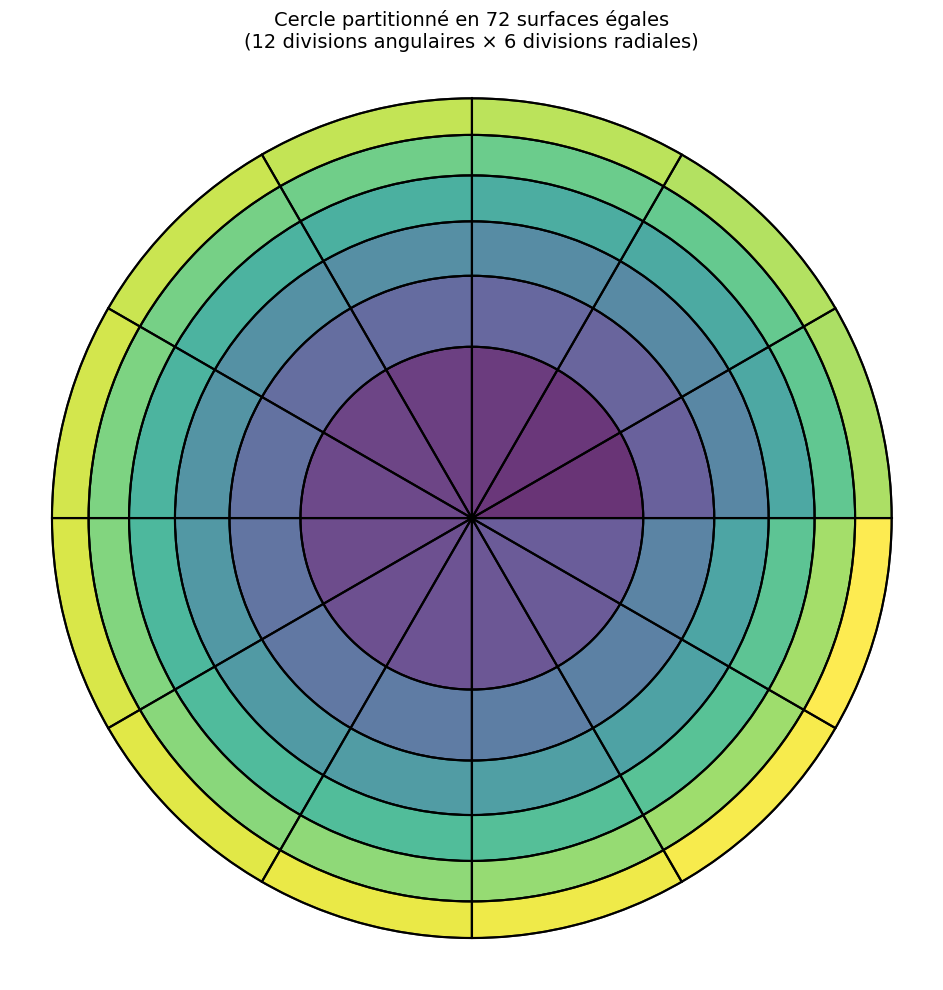

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.collections import PatchCollection

def cercle_partitionne(n_angular=8, n_radial=4, radius=1):
    """
    Crée un cercle partitionné en surfaces égales.
    
    Parameters:
    - n_angular: nombre de divisions angulaires
    - n_radial: nombre de divisions radiales
    - radius: rayon du cercle
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Pour avoir des surfaces égales radialement, les rayons doivent suivre
    # r_i = R * sqrt(i/n) car l'aire est proportionnelle à r²
    rayons = [radius * np.sqrt(i / n_radial) for i in range(n_radial + 1)]
    
    # Angles équidistants
    angles = np.linspace(0, 360, n_angular + 1)
    
    # Créer les patches (secteurs)
    patches = []
    colors = []
    
    # Colormap pour différencier les secteurs
    cmap = plt.cm.viridis
    
    for i in range(n_radial):
        for j in range(n_angular):
            # Créer un secteur annulaire
            wedge = Wedge(
                center=(0, 0),
                r=rayons[i + 1],
                theta1=angles[j],
                theta2=angles[j + 1],
                width=rayons[i + 1] - rayons[i]
            )
            patches.append(wedge)
            # Couleur basée sur la position
            colors.append((i * n_angular + j) / (n_radial * n_angular))
    
    # Créer la collection de patches
    collection = PatchCollection(patches, cmap=cmap, alpha=0.8, edgecolor='black', linewidth=1.5)
    collection.set_array(np.array(colors))
    ax.add_collection(collection)
    
    # Tracer les lignes de séparation radiales
    for angle in angles[:-1]:
        angle_rad = np.radians(angle)
        ax.plot([0, radius * np.cos(angle_rad)], 
                [0, radius * np.sin(angle_rad)], 
                'k-', linewidth=1.5)
    
    # Tracer les cercles de séparation
    for r in rayons:
        circle = plt.Circle((0, 0), r, fill=False, color='black', linewidth=1.5)
        ax.add_patch(circle)
    
    # Configuration des axes
    ax.set_xlim(-radius * 1.1, radius * 1.1)
    ax.set_ylim(-radius * 1.1, radius * 1.1)
    ax.set_aspect('equal')
    ax.set_title(f'Cercle partitionné en {n_angular * n_radial} surfaces égales\n'
                 f'({n_angular} divisions angulaires × {n_radial} divisions radiales)', 
                 fontsize=14)
    ax.axis('off')
    
    # Vérification des surfaces
    surface_totale = np.pi * radius**2
    surface_secteur = surface_totale / (n_angular * n_radial)
    print(f"Surface totale du cercle: {surface_totale:.4f}")
    print(f"Surface de chaque secteur: {surface_secteur:.4f}")
    print(f"Nombre total de secteurs: {n_angular * n_radial}")
    
    # Afficher les rayons calculés
    print(f"\nRayons des cercles concentriques: {[f'{r:.3f}' for r in rayons]}")
    
    plt.tight_layout()
    return fig, ax

# Exemple d'utilisation
fig, ax = cercle_partitionne(n_angular=8, n_radial=5)
plt.show()

# Autre exemple avec plus de divisions
fig2, ax2 = cercle_partitionne(n_angular=12, n_radial=6)
plt.show()